# Reslice Module

The function ``reslice_image`` is used to deform images aligned to the individual anatomical image into SUIT space. We assume you have produced in the previous steps an isolation mask (``sub-ex_T1w_cerebellum_dseg.nii.gz``) and a deformation file (``sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz``). 

In [1]:
# Import necessary packages
from nilearn import plotting
import SUITPy as suit
import nibabel as nib

## Reslice image without mask
The reslice function takes at the minimum 2 input parameters: The list of source images (the images that you want to reslice) and the deformation map.

In [5]:
output_img = suit.reslice_image(source_image = 'sub-ex_T1w.nii.gz',
        deformation = 'sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz')

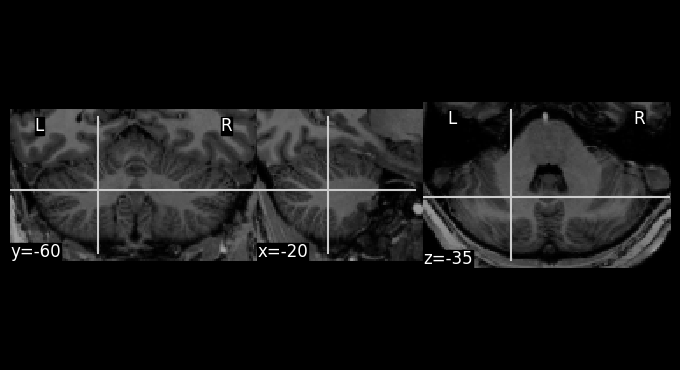

In [7]:
plotting.plot_anat(output_img,cut_coords=(-20,-60,-35))

To save the resliced image, use: 

``nib.save(output_img, "img1.nii")``

## Reslice image with mask 
For cerebellar data analysis, we strongly recommend to mask functional data when reslicing. This prevents un-wanted spill-over of neocortical signal into the cerebellum during subsequent smoothing.

In [9]:
output_img = suit.reslice_image(source_image = 'sub-ex_T1w.nii.gz',
        deformation = 'sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz',
        mask='sub-ex_T1w_cerebellum_dseg.nii.gz')


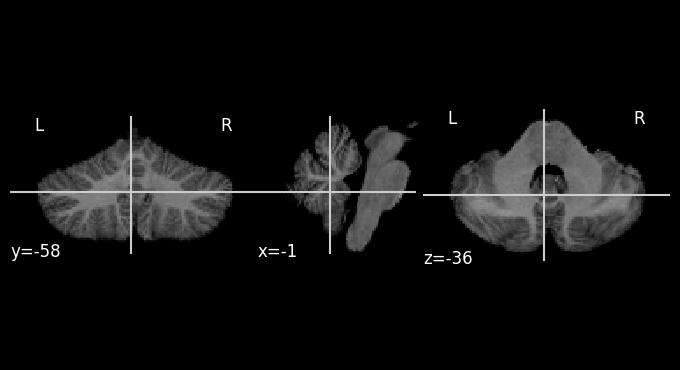

In [10]:
plotting.plot_anat(output_img)

## Specify voxel size
By default, the new image will be resliced into the same resolution and bounding box as template (1mm resolution for SUIT). For functional data we often would like a different resolution. For this, you can simply specify the voxel size. 

In [11]:
output_img = suit.reslice_image(source_image = 'sub-ex_T1w.nii.gz',
        deformation = 'sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz',
        mask='sub-ex_T1w_cerebellum_dseg.nii.gz',
        voxelsize=(2,2,2))

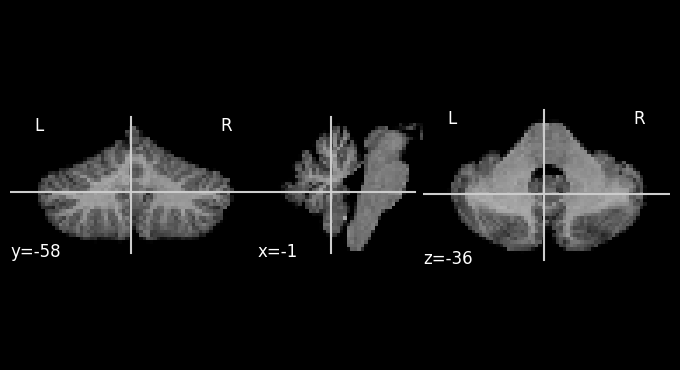

In [12]:
plotting.plot_anat(output_img)

In [13]:
# Voxel size has been changed.
output_img.shape

(71, 48, 44)

## Specify output dimensions and affine transformation matrix
To fully specify the output dimensions of the data, you can also specify an affine transformation and a image dimensions 

In [14]:
output_img = suit.reslice_image(source_image = 'sub-ex_T1w.nii.gz',
        deformation = 'sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz',
        mask='sub-ex_T1w_cerebellum_dseg.nii.gz',
        imagedim = [100,50,30],
        affine = output_img.affine)

(100, 50, 30)

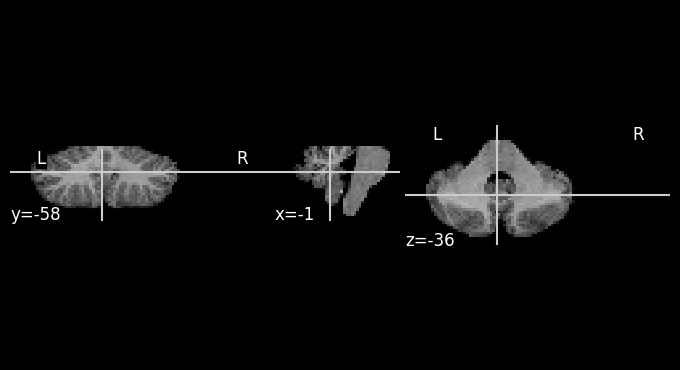

In [15]:
plotting.plot_anat(output_img)
output_img.shape

## Reslice atlas to individual space using the inverse deformation

If you want to bring a group template of atlas into the space of an individual, you need the inverse deformation file. 
To save that inverse deformation set `write_inv_deformation` to `True`. 

In [ ]:
# Set write_inv_deformation=True to save the inverse deformation file.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 write_inv_deformation=True,
                 verbose = 0)

The inverse deformation is saved as `sub-ex_T1w_from-SUIT_mode-image_xfm.nii.gz`. 

We can then reslice any atlas, such as the Buckner networks, from SUIT into the individual space. 

*Note: because the atlas is a label file, we need to use nearest-neighbour interpolation here*

In [ ]:
# reslice the Buckner atlas from SUIT space to individual space using the inverse deformation.
buckner_img = suit.reslice_image('Buckner_17Networks.nii',
                   deformation = results['inv_deformation'],
                   interp=0)

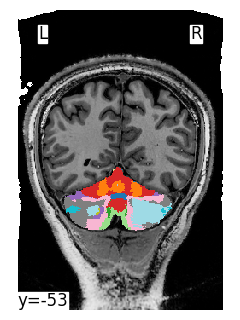

In [ ]:
plotting.plot_img(buckner_img,display_mode='y',threshold=0.1, cut_coords=[-53.0], bg_img='sub-ex_T1w.nii.gz',colorbar=False,cmap='tab20')


## Using deformation maps from SUIT (Matlab)
The reslice module can also be used to reslice images from individuals that were normalized with the MATLAB version of the [SUIT toolbox](https://github.com/jdiedrichsen/suit). We assume that you have run `suit_normalize_dartel.m` ([see here for documentation](https://www.diedrichsenlab.org/imaging/suit_function.htm#norm_dartel)). The reslice module requires the result of the normalization step as a non-linear deformation file. In Matlab you can produce this file using the following command:

```matlab
suit_save_darteldef(<name>, 'wdir', <dir>)
```

Where `<name>` is the name of the original anatomical and `<dir>` the suit working directory (defaults to current directory). This function produces `y_<name>_suitdef.nii` as an output. This image can then be used instead of the `*_xfm.nii.gz` file in SUITPy to reslice anatomical and functional images into atlas space.
